Analysis Notebook

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath("../src"))

from herschel_bulkley_model import herschel_bulkley_shear_stress

Generate Rheology Curve

In [2]:
yield_stress = 6
K = 0.4
n = 0.65

shear_rates = np.linspace(0, 500, 120)

shear_stress = herschel_bulkley_shear_stress(
    yield_stress,
    K,
    n,
    shear_rates
)

Plot Rheology Curve

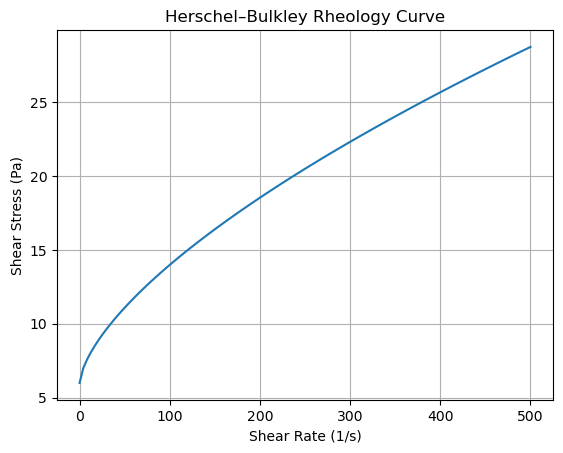

In [3]:
plt.figure()

plt.plot(shear_rates, shear_stress)

plt.xlabel("Shear Rate (1/s)")
plt.ylabel("Shear Stress (Pa)")
plt.title("Herschel–Bulkley Rheology Curve")

plt.grid(True)
plt.savefig("../results/herschel_bulkley_curve.png", dpi=300)
plt.show()

Update Notebook Imports

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath("../src"))

from herschel_bulkley_model import (
    herschel_bulkley_shear_stress,
    temperature_adjusted_K
)

Define Surface Rheology

In [5]:
yield_stress = 6
K_surface = 0.45
n = 0.65

surface_temp = 30
activation_energy = 5000

Define Downhole Temperature

In [6]:
depth = 2500
geothermal_gradient = 0.03

downhole_temp = surface_temp + geothermal_gradient * depth

Compute Temperature-Adjusted K

In [7]:
K_downhole = temperature_adjusted_K(
    K_surface,
    activation_energy,
    surface_temp,
    downhole_temp
)

print("Surface K:", K_surface)
print("Downhole K:", K_downhole)

Surface K: 0.45
Downhole K: 0.30362351744708793


Generate Rheology Curves

In [8]:
shear_rates = np.linspace(1, 500, 120)

stress_surface = herschel_bulkley_shear_stress(
    yield_stress,
    K_surface,
    n,
    shear_rates
)

stress_downhole = herschel_bulkley_shear_stress(
    yield_stress,
    K_downhole,
    n,
    shear_rates
)

Plot Comparison

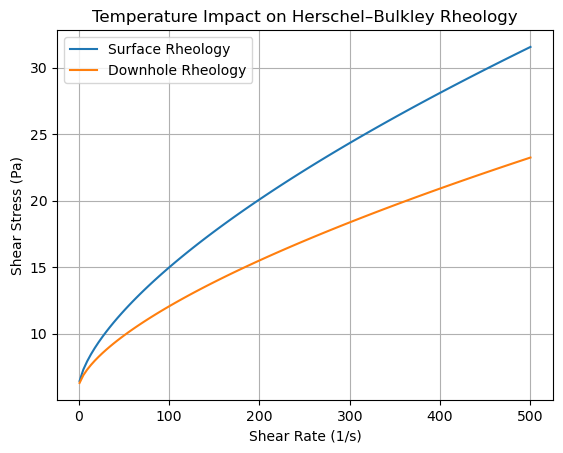

In [9]:
plt.figure()

plt.plot(shear_rates, stress_surface, label="Surface Rheology")
plt.plot(shear_rates, stress_downhole, label="Downhole Rheology")

plt.xlabel("Shear Rate (1/s)")
plt.ylabel("Shear Stress (Pa)")

plt.title("Temperature Impact on Herschel–Bulkley Rheology")

plt.legend()
plt.grid(True)
plt.savefig("../results/thermal_herschel_bulkley.png", dpi=300)
plt.show()

Update Notebook Imports

In [ ]:
from herschel_bulkley_model import (
    apparent_viscosity_hb,
    annular_shear_rate,
    pressure_gradient_hb
)

Define Well Parameters and compute shear rate

In [11]:
flow_rate = 0.03        # m3/s
hole_diameter = 0.216   # 8.5 in
pipe_diameter = 0.127   # 5 in

shear_rate = annular_shear_rate(
    flow_rate,
    hole_diameter,
    pipe_diameter
)

print("Annular Shear Rate:", shear_rate)

Annular Shear Rate: 112.47272749024867


Compute Apparent Viscosity

In [12]:
mu_surface = apparent_viscosity_hb(
    yield_stress,
    K_surface,
    n,
    shear_rate
)   # for surface mud

mu_downhole = apparent_viscosity_hb(
    yield_stress,
    K_downhole,
    n,
    shear_rate
)   # for downhole mud

print("Surface Apparent Viscosity:", mu_surface)
print("Downhole Apparent Viscosity:", mu_downhole)
# mu_downhole < mu_surface since Hot mud flows easier.

Surface Apparent Viscosity: 0.13951425999135336
Downhole Apparent Viscosity: 0.11148544239330331


Compute Velocity

In [13]:
annular_area = np.pi * (hole_diameter**2 - pipe_diameter**2) / 4
velocity = flow_rate / annular_area

hydraulic_diameter = hole_diameter - pipe_diameter

Pressure Gradient

In [14]:
dp_surface = pressure_gradient_hb(
    mu_surface,
    velocity,
    hydraulic_diameter
) # for surface mud


dp_downhole = pressure_gradient_hb(
    mu_downhole,
    velocity,
    hydraulic_diameter
) # for downhole mud

print("Surface Pressure Gradient:", dp_surface)
print("Downhole Pressure Gradient:", dp_downhole)

# dp_downhole < dp_surface because viscosity dropped.

Surface Pressure Gradient: 705.2381728094917
Downhole Pressure Gradient: 563.55378792952


Compute ECD

In [15]:
mud_weight = 10.5
depth = 2500

ecd_surface = mud_weight + dp_surface * depth / (0.052 * depth)
ecd_downhole = mud_weight + dp_downhole * depth / (0.052 * depth)

print("Surface ECD:", ecd_surface)
print("Downhole ECD:", ecd_downhole)

# Now ECD reflects rheology changes.

Surface ECD: 13572.772554028688
Downhole ECD: 10848.072844798462


Import Both Models

In [ ]:
from bingham_model import calculate_bingham_parameters
from herschel_bulkley_model import apparent_viscosity_hb

Define Mud Rheology

In [ ]:
theta600 = 45
theta300 = 30

PV, YP = calculate_bingham_parameters(theta600, theta300)

print("Plastic Viscosity:", PV)
print("Yield Point:", YP)

Convert Units

In [ ]:
yield_stress = YP * 0.4788   # lb/100ft² → Pa
plastic_viscosity = PV / 1000

Define Herschel–Bulkley Parameters

In [ ]:
K = 0.45
n = 0.65

Compute Shear Rate

In [ ]:
shear_rate = annular_shear_rate(
    flow_rate,
    hole_diameter,
    pipe_diameter
)

Apparent Viscosity Comparison

In [ ]:
mu_bingham = plastic_viscosity + (yield_stress / shear_rate) # Bingham plastic model

mu_hb = apparent_viscosity_hb(
    yield_stress,
    K,
    n,
    shear_rate
)     # Herschel–Bulkley model

print("Bingham Viscosity:", mu_bingham)
print("Herschel–Bulkley Viscosity:", mu_hb)

# HB < Bingham because HB captures shear thinning better.